<a href="https://colab.research.google.com/github/MatheusRegoDev/AMnS-projects-2025.2-BTI-UFRN/blob/main/AMnS_Unid_III_Exercicio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMD3003 - Aprendizado de Máquina Não-Supervisionado - Projeto da Unidade III**

**Discentes:**

* José Manoel Freitas da Silva (Mat.: 20220039467)
* José Victor do Nascimento Ferreira (Mat.:	20220037248)
* Matheus Rodrigues do Rego (Mat.: 20220005440)
*
*

## **Introdução**

O presente projeto visa analisar informações de métricas e metadados de músicas presentes no **Spotify** de modo a identificar possíveis subgêneros musicais formados a partir de canções com sonoridade similar, mas catalogadas como gêneros diferentes.

Para isso, a seguinte pesquisa contará com métodos de clusterização e redução de dimensionalidade para agrupar cada elemento com base em atributos como *danceability*, *energy*, *acousticness*, para então compará-los entre si através da coluna *track_genre*.

Ao final, é esperado que se possa identificar relações entre músicas de diferentes gêneros, com o intuito de promover a discussão sobre algoritmos de recomendação.


##**Implementação**

O código de análise segue o dataset **🎹 Spotify Tracks Dataset**, disponível no [Kaggle](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset?select=dataset.csv). O dataset compila informações de cerca de 114.000 músicas presentes no Spotify com 125 diferentes gêneros musicais.

### Importações iniciais

In [1]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install kagglehub

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os



#remove warnings
warnings.filterwarnings('ignore')

In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/matheus/.cache/kagglehub/datasets/maharshipandya/-spotify-tracks-dataset/versions/1


### Explorando o dataset

In [14]:
path = "/home/matheus/.cache/kagglehub/datasets/maharshipandya/-spotify-tracks-dataset/versions/1"
os.listdir(path)

spotify_db = pd.read_csv(path + "/dataset.csv")

print(f"Shape do database: {spotify_db.shape}")
print("-----------------------------------------------------------------------")
print("Informacoes do db")
print(spotify_db.info())
print("-----------------------------------------------------------------------")
print("Colunas:")
spotify_db.columns

Shape do database: (114000, 21)
-----------------------------------------------------------------------
Informacoes do db
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [15]:
print("Primeiras 5 linhas do")
spotify_db.head()

Primeiras 5 linhas do


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [17]:
spotify_db.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### Normalização e limpeza

In [16]:
# Remover linhas que contêm valores nulos
spotify_db = spotify_db.dropna()
# Verificar tamnho após limpeza
print(f"Tamanho após remover valores nulos: {spotify_db.shape}")

# Lista de colunas numéricas de áudio
audio_features = [
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'speechiness', 'tempo', 'valence'
]

# Criar matriz X apenas com o que importa para o algoritmo
X = spotify_db[audio_features]
# Verificar se todos são numéricos
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna() # Garante que a conversão não gerou nulos

Tamanho após remover valores nulos: (113999, 21)


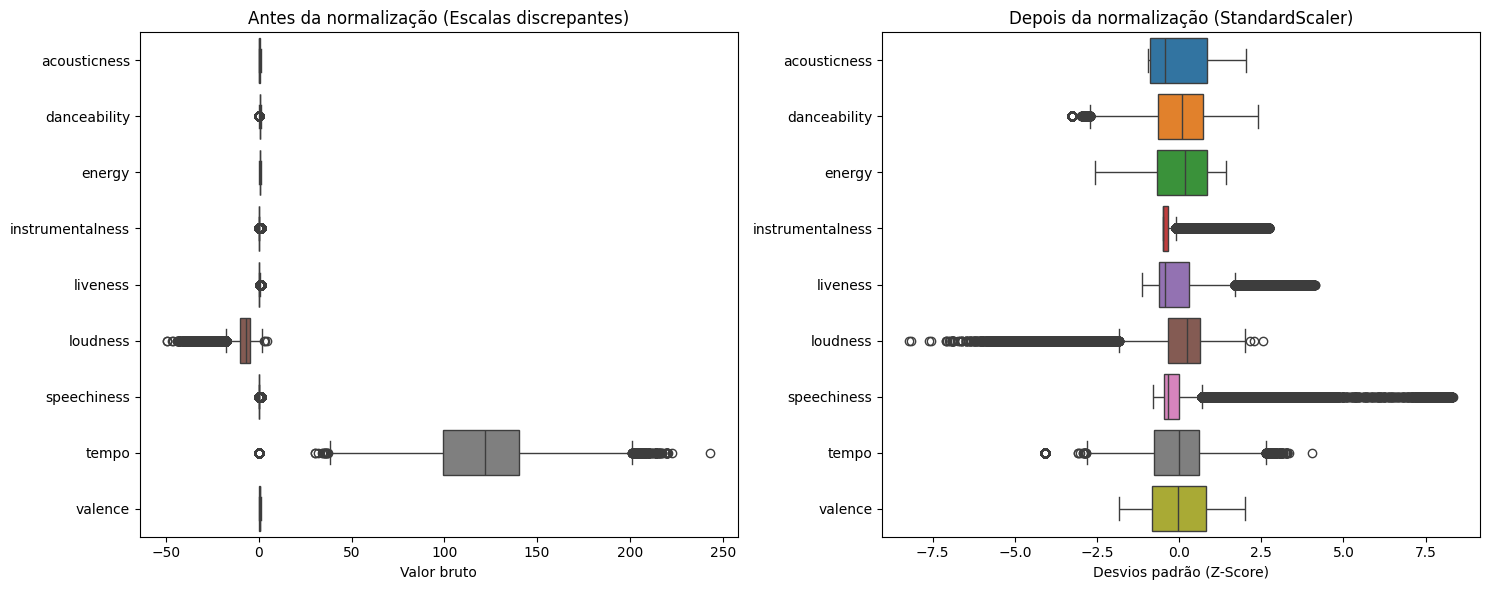

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X.columns,
    index=X.index # Mantém o índice original para cruzar com os nomes das músicas depois
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Dados originais (bagunçados)
sns.boxplot(data=X, ax=axes[0], orient='h')
axes[0].set_title('Antes da normalização (Escalas discrepantes)')
axes[0].set_xlabel('Valor bruto')

# Gráfico 2: Dados normalizados (alinhados)
sns.boxplot(data=X_scaled, ax=axes[1], orient='h')
axes[1].set_title('Depois da normalização (StandardScaler)')
axes[1].set_xlabel('Desvios padrão (Z-Score)')

plt.tight_layout()
plt.show()

Realizamos a limpeza dos dados eliminando valores nulos. Além disso, para a normalização, aplicamos o método StandardScaler (Z-score normalization). Essa etapa foi fundamental pois atributos como 'Tempo' (escala de 50-200) e 'Loudness' (escala de -60 a 0) possuíam magnitudes muito superiores a atributos normalizados como 'Danceability' (0-1), o que enviesaria o cálculo de distância euclidiana no algoritmo K-Means, por exemplo.

## **Agrupamento e análise**

### Algoritmos de clusterização

1.   Item da lista
2.   Item da lista



**_Scripts retirados de exercícios anteriores_**

### Ferramentas de redução de dimensionalidade

**_Scripts retirados de exercícios anteriores_**

### Aplicando redução de dimensionalidade

A aplicação do algoritmo PCA (Principal Component Analysis) neste projeto cumpre três funções estratégicas fundamentais para o sucesso da clusterização e interpretação dos dados musicais:

1. O conjunto de dados possui 9 dimensões de áudio (features como danceability, energy, tempo, etc.). Como a percepção humana é limitada a três dimensões espaciais, é impossível visualizar a estrutura global dos dados em seu estado bruto. O PCA projeta esses dados em um subespaço de menor dimensão (2D), preservando a maior quantidade possível de informação (variância). Isso nos permite gerar gráficos de dispersão (Scatter Plots) onde a distância visual entre dois pontos reflete, aproxima e resume a dissimiliaridade sonora entre duas músicas.
2. Alguns atributos musicais apresentam alta correlação linear. Por exemplo, faixas com alta energy tendem a ter alto loudness (volume). Algoritmos baseados em distância euclidiana, como o K-Means, são sensíveis a essa redundância, pois acabam "contabilizando duas vezes" a mesma característica latente, enviesando o agrupamento. Ao calcularmos a matriz de covariância e seus autovetores (conforme nossa implementação própria do algoritmo), o PCA gera componentes que são ortogonais entre si. Isso garante que cada nova dimensão represente uma característica única e não correlacionada, entregando dados mais "limpos" para o agupamento.
3. Em espaços de alta dimensão, a noção de distância euclidiana torna-se menos discriminativa — a diferença de distância entre o vizinho mais próximo e o mais distante tende a diminuir, fazendo com que os clusters pareçam uma nuvem difusa e uniforme. Ao concentrar a variância nos primeiros Componentes Principais e descartar as dimensões de menor autovalor (que frequentemente contêm ruído), aumentamos a densidade dos grupos e a robustez do algoritmo de clusterização.

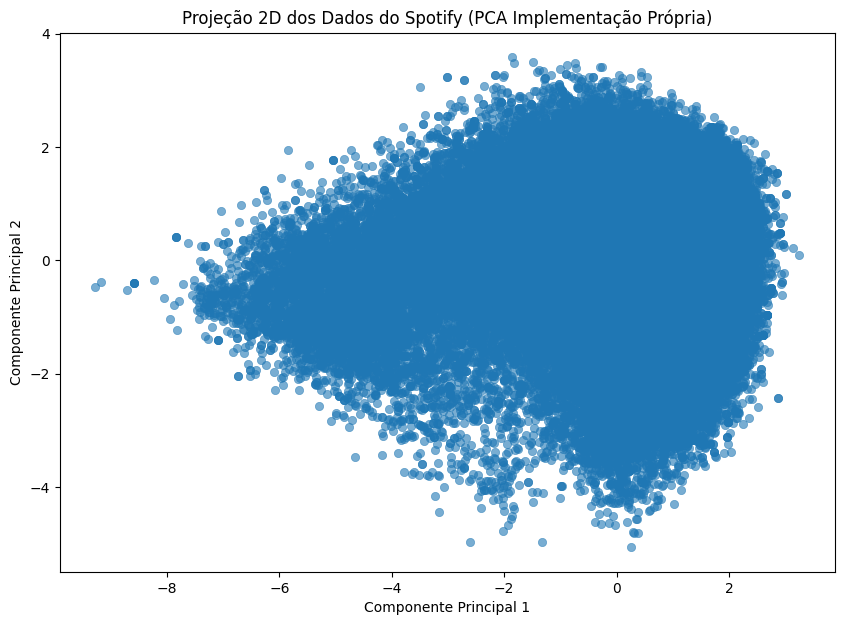

In [18]:
from sklearn.decomposition import PCA
pca_custom = PCA(n_components=2)

X_projected = pca_custom.fit_transform(X_scaled.values)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_projected[:, 0],
    y=X_projected[:, 1],
    alpha=0.6,
    edgecolor=None
)

plt.title('Projeção 2D dos Dados do Spotify (PCA Implementação Própria)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

### Aplicar algoritmo de clustericação

Aplicaremos o K-means para encontrar grupos musicais.

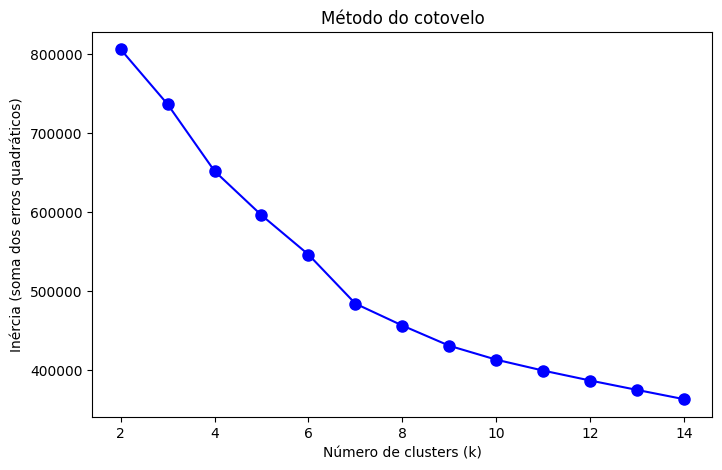

In [40]:
from sklearn.cluster import KMeans
X_numpy = X_scaled.values

def calcular_inercia(X, centroids, labels):
    inercia = 0
    for i, centroide in enumerate(centroids):
        pontos_do_cluster = X[labels == i]

        # Calcula a distância quadrada de cada ponto até seu centróide e soma
        distancias_quadradas = np.sum((pontos_do_cluster - centroide)**2)
        inercia += distancias_quadradas
    return inercia

inercias = []
k_range = range(2, 15)

for k in k_range:
    modelo_temp = KMeans(n_clusters=k, random_state=42)
    modelo_temp.fit(X_numpy)

    inercia_atual = calcular_inercia(
        X_numpy,
        modelo_temp.cluster_centers_,
        modelo_temp.labels_
    )
    inercias.append(inercia_atual)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inercias, 'bo-', markersize=8)
plt.title('Método do cotovelo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia (soma dos erros quadráticos)')
plt.show()

Analisando o gráfico de Número de clusters (k) por Inércia podemos constatar que o número ótimo de clusters gira em torno de 7, seguindo o método do cotovelo.

In [34]:
kmeans = KMeans(n_clusters=10, max_iter=300, random_state=42)
kmeans.fit(X_numpy)
labels = kmeans.labels_
X['cluster_id'] = labels

#Add labels a spotify_db para facilitar a vida
spotify_db['cluster_id'] = labels

X


,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,cluster_id
0,0.0322,0.676,0.4610,0.000001,0.3580,-6.746,0.1430,87.917,0.7150,4
1,0.9240,0.420,0.1660,0.000006,0.1010,-17.235,0.0763,77.489,0.2670,9
2,0.2100,0.438,0.3590,0.000000,0.1170,-9.734,0.0557,76.332,0.1200,9
3,0.9050,0.266,0.0596,0.000071,0.1320,-18.515,0.0363,181.740,0.1430,9
4,0.4690,0.618,0.4430,0.000000,0.0829,-9.681,0.0526,119.949,0.1670,9
...,...,...,...,...,...,...,...,...,...,...
113995,0.6400,0.172,0.2350,0.928000,0.0863,-16.393,0.0422,125.995,0.0339,1
113996,0.9940,0.174,0.1170,0.976000,0.1050,-18.318,0.0401,85.239,0.0350,1
113997,0.8670,0.629,0.3290,0.000000,0.0839,-10.895,0.0420,132.378,0.7430,2
113998,0.3810,0.587,0.5060,0.000000,0.2700,-10.889,0.0297,135.960,0.4130,2


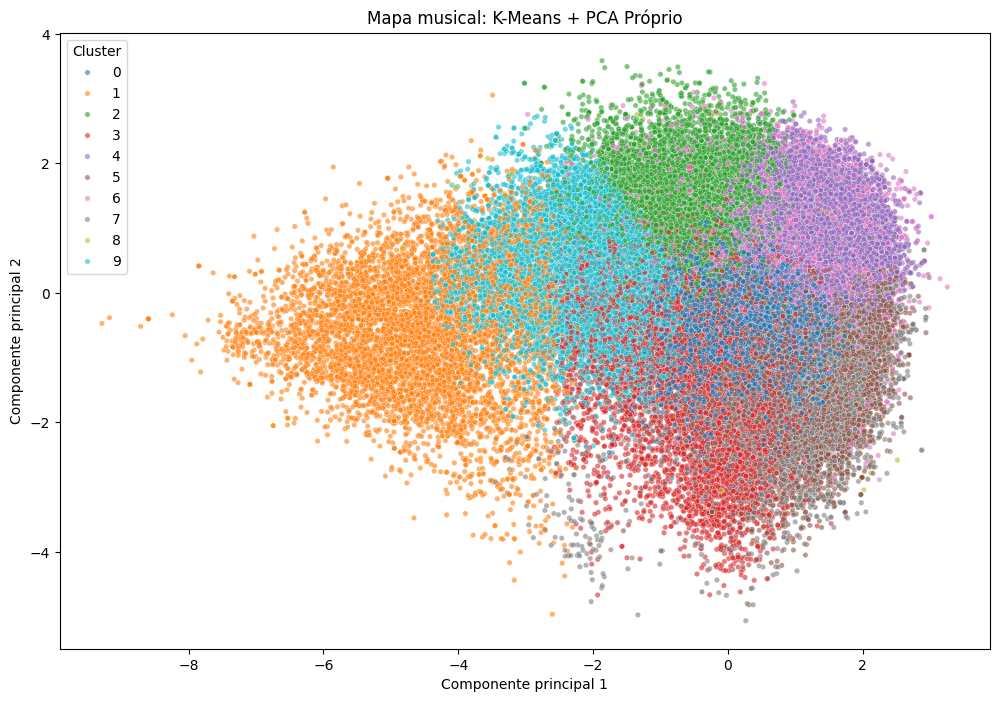

In [38]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_projected[:, 0],
    y=X_projected[:, 1],
    hue=X['cluster_id'], # Usando os labels do seu K-Means
    palette='tab10',
    alpha=0.6,
    s=15
)
plt.title('Mapa musical: K-Means + PCA Próprio')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='Cluster')
plt.show()

#### Construir sistema de recomendação

Para a etapa de exploração de similaridade e recomendação, utilizamos o algoritmo NearestNeighbors da biblioteca Scikit-Learn. Optamos por esta implementação otimizada, configurada com a métrica de distância de cosseno, por ser um padrão da indústria para sistemas de recomendação baseados em filtragem colaborativa e conteúdo, permitindo identificar vetores de áudio com orientações similares no espaço multidimensional.

In [39]:
from sklearn.neighbors import NearestNeighbors

nn_model = NearestNeighbors(n_neighbors=6, metric='cosine')
nn_model.fit(X_scaled)

def recomendar_musica(track_name, artist_name=None):
    query = spotify_db[spotify_db['track_name'].str.contains(track_name, case=False)]
    if query.empty:
        return "Música não encontrada."

    song_idx = query.index[0]
    song_features = spotify_db.loc[song_idx]

    # Remove features em string e normaliza -1<x<1
    song_values = song_features[audio_features].values.reshape(1, -1)

    distances, indices = nn_model.kneighbors(song_values)
    indices_vizinhos = indices[0] # Lista de índices (inclui a própria música)
    print(song_features)
    # --- ETAPA B: EXIBIÇÃO COM CONTEXTO (Usa seu K-Means) ---
    print(f"🎵 MÚSICA ALVO: {song_features['track_name']} - {song_features['artists']}")
    print(f"🏷️  PERTENCE AO CLUSTER (Seu K-Means): {song_features['cluster_id']}")
    print("-" * 60)

    recomendacoes_df = spotify_db.iloc[indices_vizinhos].copy()

    for i, (_, row) in enumerate(recomendacoes_df.iloc[1:].iterrows()):
        match_cluster = "✅" if row['cluster_id'] == song_features['cluster_id'] else "⚠️"
        print(f"{i+1}. {row['track_name']} ({row['artists']} - Cluster Row:{row['cluster_id']})")
        print(f"   Cluster: {row['cluster_id']} {match_cluster} | Distância: {distances[0][i+1]:.4f}")

# Teste o sistema
recomendar_musica("One Kiss")

Unnamed: 0                                 13549
track_id                  3KdmscXY5jO7JiB2AO0a1f
artists                                 Ten City
album_name                            Foundation
track_name          One Kiss Will Make It Better
popularity                                     7
duration_ms                               295773
explicit                                   False
danceability                               0.795
energy                                     0.526
key                                            6
loudness                                 -15.257
mode                                           0
speechiness                                0.175
acousticness                               0.131
instrumentalness                         0.00909
liveness                                  0.0412
valence                                    0.822
tempo                                    103.983
time_signature                                 4
track_genre         